# Homework 4

*CCD Reductions* <br>
*Riddhi Patel* <br>
*March 2026*





---
## Contents
* [Setup](#setup)
    * [Import Block](#import)
    * [Read in Files](#files)
    * [Convert File Lists to Arrays](#arrays)
* [Image Analysis](#image_analysis)
* [Overscan Subtraction and Trimming](#os_sub)
* [Bias Correction](#bc)
    * [Characterizing Bias Files](#bias_char)
    * [Creating a Master Bias](#master_bias)
    * [Characterize Master Bias](#master_bias_char)
    * [Bias Correcting](#bias_correct)
    * [Check _otz Files](#bias_check)
* [Darks Analysis](#dark)
    * [Characterizing Dark Files](#dark_char)
    * [Creating a Master Dark](#master_dark)
* [Final Code](#final)

---


## Setup <a class="anchor" id="setup"></a>

This section serves as a setup for CCD Reduction calculations done later! I started to get overwhelmed with all of the files and data types :(, so I formatted everything in an easily-accessible way. Hopefully this also makes things much easier to reproduce later!

### Import Block <a class="anchor" id="import"></a>

In [16]:
# IMPORT BLOCK

import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib import rc
%matplotlib inline
from astropy.visualization import hist, ZScaleInterval
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from astropy.modeling import fitting
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D
from astropy.nddata import CCDData
from astropy import units as u
from astropy.stats import sigma_clip, mad_std
import glob
import os

### Read in Files <a class="anchor" id="files"></a>

This section simply uses glob to read in all the files we'll need for this assignment and make them into useable lists. 

It also checks to make sure we have the amount of files we expect from each section. Note: I noticed that some of the images were missing from our Imaging directory, so I made a comment off to the side and continued the assignment with what we had!

In [17]:
## DEFINE DATA DIRECTORY AND BIAS/DARKS/FLATS/SCIENCE FILES LISTS

data_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/image_combination/Imaging/'
output_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/reduced_files/'
reduced_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/reduced_files/'

bias_files = sorted(
    glob.glob(data_dir+'a09[3-9].fits') + #93-99
    glob.glob(data_dir+'a10[0-9].fits') + #100-109
    glob.glob(data_dir+'a11[0-1].fits')   #110-111
)
print('The number of biases we have is:', len(bias_files))


flat_files = sorted(
    glob.glob(data_dir+'a00[5-9].fits') + #5-9
    glob.glob(data_dir+'a01[0-9].fits') + #10-19
    glob.glob(data_dir+'a02[0-9].fits') + #20-29
    glob.glob(data_dir+'a03[0-9].fits') + #30-39
    glob.glob(data_dir+'a04[0-9].fits') + #40-49
    glob.glob(data_dir+'a05[0-9].fits') + #50-59
    glob.glob(data_dir+'a06[0-2].fits')   #60-62
)
print('The number of flats we have is:', len(flat_files))


dark_files = sorted(
    glob.glob(data_dir+'d00[1-9].fits') + #1-9
    glob.glob(data_dir+'d01[0-5].fits')  #10-15
)
print('The number of darks we have is:', len(dark_files))


pg_files = sorted(
    glob.glob(data_dir+'a06[4-9].fits') + #64-69
    glob.glob(data_dir+'a07[0-9].fits') + #70-79
    glob.glob(data_dir+'a08[0-9].fits') + #80-89
    glob.glob(data_dir+'a09[0-2].fits') + #90-92
    glob.glob(data_dir+'a13[0-9].fits') + #130-139
    glob.glob(data_dir+'a20[2-9].fits') + #202-209
    glob.glob(data_dir+'a21[0-1].fits') + #210-211
    glob.glob(data_dir+'a22[1-9].fits') + #221-229 (We don't have any of these)
    glob.glob(data_dir+'a23[0-9].fits') + #230-239 (We only have #237-239)
    glob.glob(data_dir+'a24[0-6].fits')   #240-246
)
print('The number of PG1633 images we have is:', len(pg_files))


ngc_files = sorted(
    glob.glob(data_dir+'a15[3-9].fits') + #153-159
    glob.glob(data_dir+'a16[0-3].fits')  #160-163
)
print('The number of NGC6823 images we have is:', len(ngc_files))



The number of biases we have is: 19
The number of flats we have is: 58
The number of darks we have is: 15
The number of PG1633 images we have is: 59
The number of NGC6823 images we have is: 11


### Convert File Lists to Arrays <a class="anchor" id="arrays"></a>

This section takes the prior lists of file names, opens all the files, and converts them into numpy arrays. It also creates numpy arrays for the biassec/overscan region and the trimsec that we are interested in! This makes it easier to make plots for image analysis later!

In [18]:
## MAKES ALL OF OUR FILE LISTS INTO NUMPY ARRAY CUBES

bias_array = np.array([fits.getdata(bias) for bias in bias_files])
bias_biassec = np.array([np.concatenate((bias[:, 0:53], bias[:, 2101:]), axis=1) for bias in bias_array])
bias_trimsec = np.array([bias[:, 53:2101] for bias in bias_array])
print('Bias array shape:', bias_array.shape,
      'Bias biassec array shape:', bias_biassec.shape,
      'Bias trimsec array shape:', bias_trimsec.shape)

flat_array = np.array([fits.getdata(flat) for flat in flat_files])
flat_biassec = np.array([np.concatenate((flat[:, 0:53], flat[:, 2101:]), axis=1) for flat in flat_array])
flat_trimsec = np.array([flat[:, 53:2101] for flat in flat_array])
print('Flat array shape:', flat_array.shape,
      'Flat biassec array shape:', flat_biassec.shape,
      'Flat trimsec array shape:', flat_trimsec.shape)

dark_array = np.array([fits.getdata(dark) for dark in dark_files])
dark_biassec = np.array([np.concatenate((dark[:, 0:53], dark[:, 2101:]), axis=1) for dark in dark_array])
dark_trimsec = np.array([dark[:, 53:2101] for dark in dark_array])
print('Dark array shape:', dark_array.shape,
      'Dark biassec array shape:', dark_biassec.shape,
      'Dark trimsec array shape:', dark_trimsec.shape)

pg_array = np.array([fits.getdata(img) for img in pg_files])
pg_biassec = np.array([np.concatenate((img[:, 0:53], img[:, 2101:]), axis=1) for img in pg_array])
pg_trimsec = np.array([img[:, 53:2101] for img in pg_array])
print('PG array shape:', pg_array.shape,
      'PG biassec array shape:', pg_biassec.shape,
      'PG trimsec array shape:', pg_trimsec.shape)

ngc_array = np.array([fits.getdata(img) for img in ngc_files])
ngc_biassec = np.array([np.concatenate((img[:, 0:53], img[:, 2101:]), axis=1) for img in ngc_array])
ngc_trimsec = np.array([img[:, 53:2101] for img in ngc_array])
print('NGC array shape:', ngc_array.shape,
      'NGC biassec array shape:', ngc_biassec.shape,
      'NGC trimsec array shape:', ngc_trimsec.shape)



Bias array shape: (19, 2048, 2200) Bias biassec array shape: (19, 2048, 152) Bias trimsec array shape: (19, 2048, 2048)
Flat array shape: (58, 2048, 2200) Flat biassec array shape: (58, 2048, 152) Flat trimsec array shape: (58, 2048, 2048)
Dark array shape: (15, 2048, 2200) Dark biassec array shape: (15, 2048, 152) Dark trimsec array shape: (15, 2048, 2048)
PG array shape: (59, 2048, 2200) PG biassec array shape: (59, 2048, 152) PG trimsec array shape: (59, 2048, 2048)
NGC array shape: (11, 2048, 2200) NGC biassec array shape: (11, 2048, 152) NGC trimsec array shape: (11, 2048, 2048)


## Image/Pixel Analysis <a class="anchor" id="image_analysis"></a>

In this section, I analyze the pixel values for bias vs science images to determine what would be the best way to take out bias from our images. 

(This follows from question 5 in the homework)

In [19]:
# INDIVIDUAL BIAS IMAGES

# for bias in bias_files:
#     hdu = fits.open(bias)
#     img = hdu[0].data
#     interval = ZScaleInterval()
#     vmin, vmax = interval.get_limits(img)

#     plt.imshow(img, vmin=vmin, vmax=vmax)
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])
#     plt.title(bias[-9:])
#     plt.show()

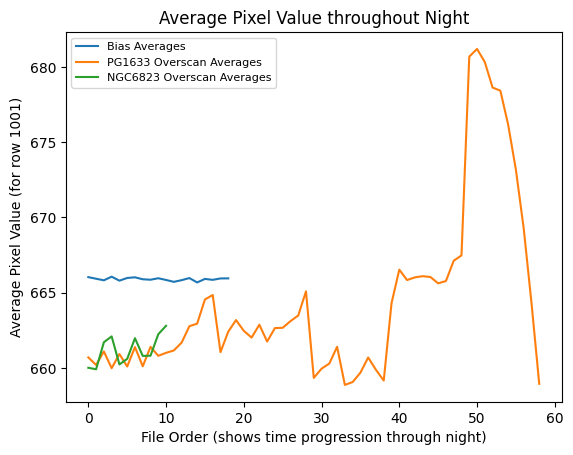

In [20]:
## PLOTS DIFFERENCE IN OVERSCAN VS BIAS IMAGE AVERAGE FOR 1 ROW 

# PRINTS CAPTURE TIME OF IMAGE TO MAKE SURE THEY ARE IN CHRONOLOGICAL ORDER
# for bias in bias_files:
#     hdu = fits.open(bias)
#     print(hdu[0].header['DATE-OBS']) #checks to make sure our files are in order of capture time

# for img in pg_files:
#     hdu = fits.open(img)
#     print(hdu[0].header['DATE-OBS']) #checks to make sure our files are in order of capture time

# for img in ngc_files:
#     hdu = fits.open(img)
#     print(hdu[0].header['DATE-OBS']) #checks to make sure our files are in order of capture time

#AVERAGES ROWS OF BIAS IMAGE OR OVERSCAN REGION AND MAKES INTO NUMPY ARRAY
row_selected = 1000
bias_avg = []
for bias in bias_array:
    row_mean = np.mean(bias[row_selected, :])
    bias_avg.append(row_mean)

pg_avg = []
for img in pg_biassec:
    biassec_mean = np.mean(img[row_selected, :])
    pg_avg.append(biassec_mean)

ngc_avg = []
for img in ngc_biassec:
    biassec_mean = np.mean(img[row_selected, :])
    ngc_avg.append(biassec_mean)


#PLOTS PIXEL VALUE AVERAGES THROUGHOUT THE NIGHT FOR ONE ROW
bias_time = np.arange(0, len(bias_avg), 1)
pg_time = np.arange(0, len(pg_avg), 1)
ngc_time = np.arange(0, len(ngc_avg), 1)

plt.plot(bias_time, bias_avg, label='Bias Averages')
plt.plot(pg_time, pg_avg, label='PG1633 Overscan Averages')
plt.plot(ngc_time, ngc_avg, label = 'NGC6823 Overscan Averages')
plt.xlabel('File Order (shows time progression through night)')
plt.ylabel('Average Pixel Value (for row '+str(row_selected+1)+')')
plt.title('Average Pixel Value throughout Night')
plt.legend(fontsize=8)
plt.show()

    


I looked at many different rows for this plot. 

It looks like the average bias level from the overscan region changes drastically throughout the night while that from the bias image stays relatively flat. I think it would be a better idea to use the overscan region to subtract out bias from each image because of this discrepancy. This will give us baseline images, which we can then make a master bias from and normalize!

## Overscan Subtraction and Trimming <a class="anchor" id="os_sub"></a>

In this section, I overscan subtract each of my files (bias, flats, darks, and science images). I used ccdproc to do this!

Then, I trim them by using python indexing because it was easier for me to understand rather than mess with ccdproc's trim_image.

(This follows from question 6 in the homework)

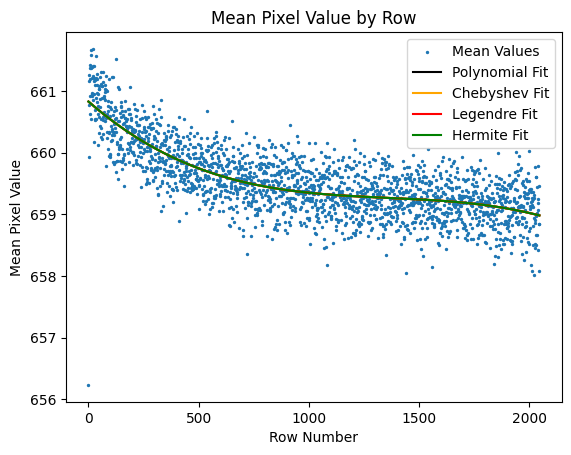

In [21]:
hdu = fits.open(data_dir+'a130.fits')
img = hdu[0].data
img_overscan = np.concatenate((img[:, 0:53], img[:, 2101:2200]), axis=1)

row_range = np.arange(0, len(img_overscan), 1)
means = []
for row in row_range:
    mean = np.mean(img_overscan[row, :])
    means.append(mean)

degree = 3
poly_model_coeff = np.polyfit(row_range, means, degree)
poly_model = np.poly1d(poly_model_coeff)

chebyshev_model = np.polynomial.Chebyshev.fit(row_range, means, deg=degree)
legendre_model = np.polynomial.Legendre.fit(row_range, means, deg=degree)
hermite_model = np.polynomial.Hermite.fit(row_range, means, deg=degree)

plt.scatter(row_range, means, s=2, label='Mean Values')
plt.plot(row_range, poly_model(row_range), label='Polynomial Fit', color='black')
plt.plot(row_range, chebyshev_model(row_range), label='Chebyshev Fit', color='orange')
plt.plot(row_range, legendre_model(row_range), label='Legendre Fit', color='red')
plt.plot(row_range, hermite_model(row_range), label='Hermite Fit', color='green')
plt.plot()
plt.xlabel('Row Number')
plt.ylabel('Mean Pixel Value')
plt.title('Mean Pixel Value by Row')
plt.legend()
plt.show()

It looks like polynomial, hermite, chebyshev, and legendre fits all look very similar to each other and fit the overscan region best at degree 3. I decided to use a degree 3 polynomial fit because it is the simplest fit to understand for me personally!

In [22]:
## OVERSCAN SUBTRACT AND TRIM EVERY FILE

##This section overscan subtracts and trims one bias file to make sure the for loops below are correct!
# bias_img = fits.getdata(data_dir+'a130.fits')
# ccd = CCDData(bias_img, unit=u.adu)
# overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
# overscan_ccd = CCDData(overscan, unit=ccd.unit)

# bias_img_o = ccdp.subtract_overscan(ccd, 
#                             overscan = overscan_ccd, 
#                             overscan_axis = 1,
#                             model = Polynomial1D(degree=3)
#                             ).data
# bias_img_ot = bias_img_o[:, 53:2101]
# bias_img_t = bias_img[:, 53:2101]

# print(np.mean(bias_img), np.mean(bias_img_o), np.mean(overscan))

# interval = ZScaleInterval()
# vmin, vmax = interval.get_limits(bias_img)
# plt.imshow(bias_img, vmin=vmin, vmax=vmax)
# plt.grid(False)
# plt.xticks([])
# plt.yticks([])
# plt.title('Original Image')
# plt.show()

# vmin, vmax = interval.get_limits(bias_img_o)
# plt.imshow(bias_img_o, vmin=vmin, vmax=vmax)
# plt.grid(False)
# plt.xticks([])
# plt.yticks([])
# plt.title('Overscan Subtracted')
# plt.show()

# vmin, vmax = interval.get_limits(bias_img_t)
# plt.imshow(bias_img_t, vmin=vmin, vmax=vmax)
# plt.grid(False)
# plt.xticks([])
# plt.yticks([])
# plt.title('Trimmed')
# plt.show()

# vmin, vmax = interval.get_limits(bias_img_ot)
# plt.imshow(bias_img_ot, vmin=vmin, vmax=vmax)
# plt.grid(False)
# plt.xticks([])
# plt.yticks([])
# plt.title('OS Sub + Trim')
# plt.show()

#BIASES     
bias_o_array = []
bias_ot_array = []

for bias in bias_files:
    bias_img, header = fits.getdata(bias, header=True)
    ccd = CCDData(bias_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    bias_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    bias_img_ot = bias_img_o[:, 53:2101]

    bias_o_array.append(bias_img_o)
    bias_ot_array.append(bias_img_ot)

    original_name = os.path.basename(bias)
    new_name = os.path.splitext(original_name)[0]+'_ot.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, bias_img_ot, header, overwrite=True)




#FLATS     
flat_o_array = []
flat_ot_array = []

for flat in flat_files:
    flat_img, header = fits.getdata(flat, header=True)
    ccd = CCDData(flat_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    flat_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    flat_img_ot = flat_img_o[:, 53:2101]

    flat_o_array.append(flat_img_o)
    flat_ot_array.append(flat_img_ot)

    original_name = os.path.basename(flat)
    new_name = os.path.splitext(original_name)[0]+'_ot.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, flat_img_ot, header, overwrite=True)


#DARKS     
dark_o_array = []
dark_ot_array = []

for dark in dark_files:
    dark_img, header = fits.getdata(dark, header=True)
    ccd = CCDData(dark_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    dark_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    dark_img_ot = dark_img_o[:, 53:2101]

    dark_o_array.append(dark_img_o)
    dark_ot_array.append(dark_img_ot)

    original_name = os.path.basename(dark)
    new_name = os.path.splitext(original_name)[0]+'_ot.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, dark_img_ot, header, overwrite=True)


#PG1633    
pg_o_array = []
pg_ot_array = []

for img in pg_files:
    pg_img, header = fits.getdata(img, header=True)
    ccd = CCDData(pg_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    pg_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    pg_img_ot = pg_img_o[:, 53:2101]

    pg_o_array.append(pg_img_o)
    pg_ot_array.append(pg_img_ot)

    original_name = os.path.basename(img)
    new_name = os.path.splitext(original_name)[0]+'_ot.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, pg_img_ot, header, overwrite=True)


#NGC6823    
ngc_o_array = []
ngc_ot_array = []

for img in ngc_files:
    ngc_img, header = fits.getdata(img, header=True)
    ccd = CCDData(ngc_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    ngc_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    ngc_img_ot = ngc_img_o[:, 53:2101]

    ngc_o_array.append(ngc_img_o)
    ngc_ot_array.append(ngc_img_ot)

    original_name = os.path.basename(img)
    new_name = os.path.splitext(original_name)[0]+'_ot.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, ngc_img_ot, header, overwrite=True)


# print(len(bias_o_array))
# print(len(bias_ot_array))
# print(len(flat_o_array))
# print(len(flat_ot_array))
# print(len(dark_o_array))
# print(len(dark_ot_array))
# print(len(pg_o_array))
# print(len(pg_ot_array))
# print(len(ngc_o_array))
# print(len(ngc_ot_array))
                                

## Bias Correction <a class="anchor" id="bc"></a>

This section is about analyzing our bias and science images to decide if we should: (1) create a master bias from our overscan subtracted/trimmed bias images and (2) bias correct our overscan subtracted and trimmed science images using that master bias. 

This follows from question 7 in the homework.

### Characterizing Bias Files <a class="anchor" id="bias_char"></a>

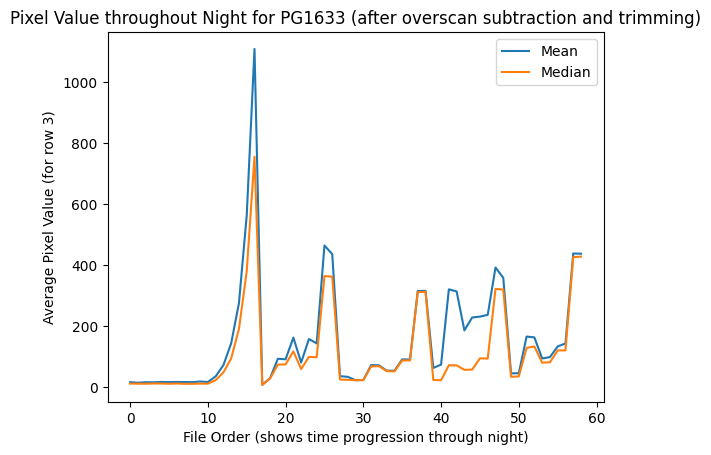

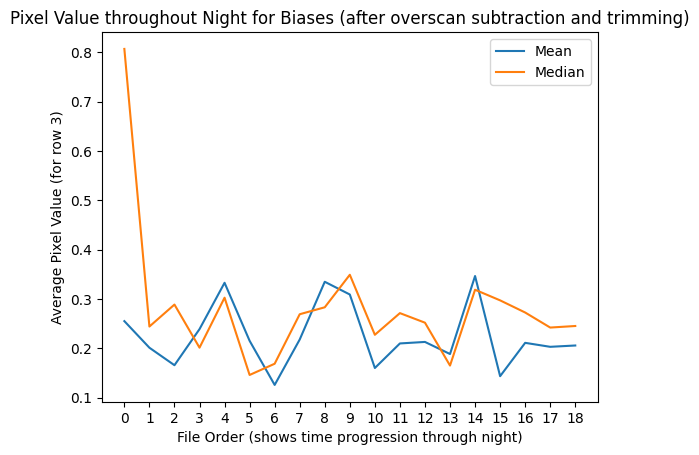

In [23]:
interval = ZScaleInterval()

row_selected = 2

bias_time = np.arange(0, len(bias_ot_array), 1)
bias_mean = np.array([np.mean(bias[row_selected, :]) for bias in bias_ot_array])
bias_median = np.array([np.median(bias[row_selected, :]) for bias in bias_ot_array])
bias_std = np.array([np.std(bias[row_selected, :]) for bias in bias_ot_array])

pg_time = np.arange(0, len(pg_ot_array), 1)
pg_mean = np.array([np.mean(img[row_selected, :]) for img in pg_ot_array])
pg_median = np.array([np.median(img[row_selected, :]) for img in pg_ot_array])
pg_std = np.array([np.std(img[row_selected, :]) for img in pg_ot_array])


plt.plot(pg_time, pg_mean, label='Mean')
plt.plot(pg_time, pg_median, label='Median')
#plt.plot(bias_time, bias_std, label='Standard Deviation')
plt.xlabel('File Order (shows time progression through night)')
plt.ylabel('Average Pixel Value (for row '+str(row_selected+1)+')')
plt.title('Pixel Value throughout Night for PG1633 (after overscan subtraction and trimming)')
plt.legend()
plt.show()

plt.plot(bias_time, bias_mean, label='Mean')
plt.plot(bias_time, bias_median, label='Median')
#plt.plot(bias_time, bias_std, label='Standard Deviation')
plt.xticks(bias_time)
plt.xlabel('File Order (shows time progression through night)')
plt.ylabel('Average Pixel Value (for row '+str(row_selected+1)+')')
plt.title('Pixel Value throughout Night for Biases (after overscan subtraction and trimming)')
plt.legend()
plt.show()

I think it makes sense to combine them into one master file because they have around the same mean, medians, and standard deviations. There isn't a huge change throughout the night as well. I'm going to average all of our biases to make our master bias because they are much more stable as opposed to medians (per file per row). 

### Creating a Master Bias <a class="anchor" id="master_bias"></a>

The number of biases we have is: 19


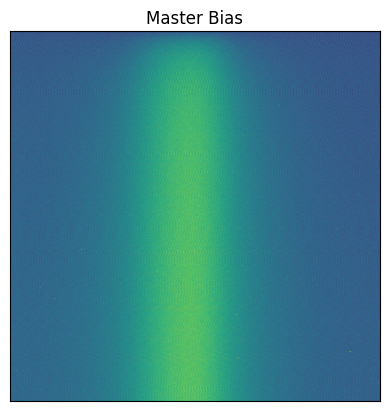

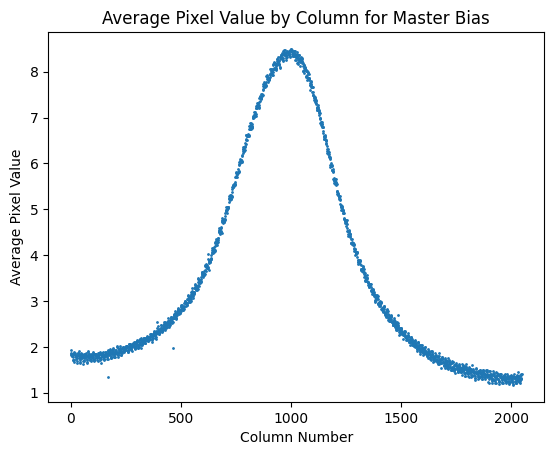

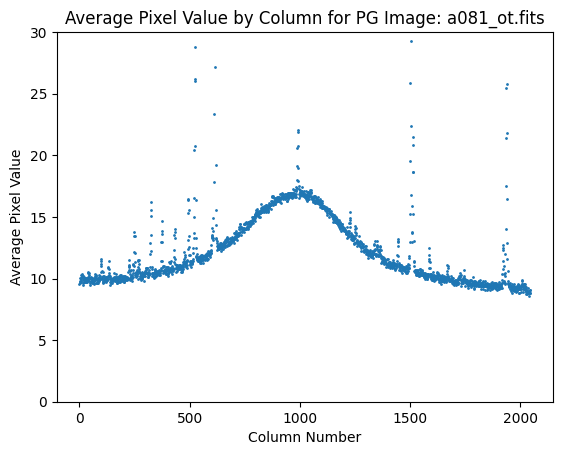

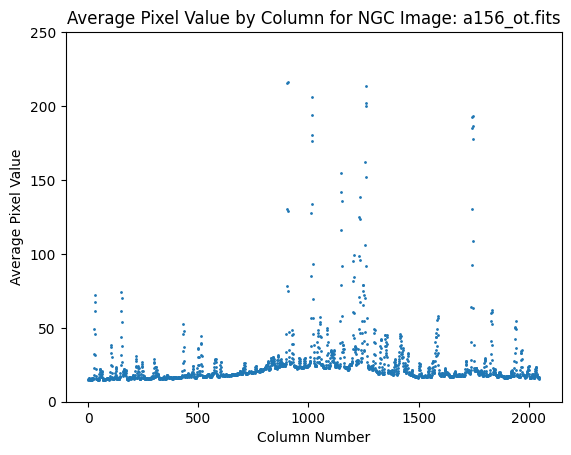

In [24]:
##CREATE MASTER BIAS

bias_ot_files = sorted(
    glob.glob(reduced_dir+'a09[3-9]_ot.fits') + #93-99
    glob.glob(reduced_dir+'a10[0-9]_ot.fits') + #100-109
    glob.glob(reduced_dir+'a11[0-1]_ot.fits')   #110-111
)
print('The number of biases we have is:', len(bias_ot_files))

master_bias = ccdp.combine(bias_ot_files,
                           unit='adu',
                           method='average',
                           sigma_clip=False)
master_bias_array = np.array(master_bias)
output_path = os.path.join(output_dir, 'master_bias.fits')
fits.writeto(output_path, master_bias_array, overwrite=True)

bias_column_range = np.arange(0, master_bias_array.shape[1], 1)
bias_means = []
for column in bias_column_range:
    mean = np.mean(master_bias_array[:, column])
    bias_means.append(mean)

pg_file = reduced_dir+'a081_ot.fits'
ngc_file = reduced_dir+'a156_ot.fits'
pg_image = fits.getdata(pg_file)
ngc_image = fits.getdata(ngc_file)
pg_column_range = np.arange(0, pg_image.shape[1], 1) #redundant because images same size, but doing for completeness
ngc_column_range = np.arange(0, ngc_image.shape[1], 1) #redundant because images same size, but doing for completeness
pg_means = []
ngc_means = []
for column in pg_column_range:
    mean = np.mean(pg_image[:, column])
    pg_means.append(mean)
for column in ngc_column_range:
    mean = np.mean(ngc_image[:, column])
    ngc_means.append(mean)




master_bias_file = reduced_dir+'master_bias.fits'
master_bias_image = fits.getdata(master_bias_file)
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(master_bias_image)
plt.imshow(master_bias_image, vmin=vmin, vmax=vmax)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('Master Bias')
plt.show()

# for bias in bias_ot_array:
#     vmin, vmax = interval.get_limits(master_bias)
#     plt.imshow(master_bias, vmin=vmin, vmax=vmax)
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])
#     plt.show()

plt.scatter(bias_column_range, bias_means, s=1)
plt.xlabel('Column Number')
plt.ylabel('Average Pixel Value')
plt.title('Average Pixel Value by Column for Master Bias')
plt.show()

plt.scatter(pg_column_range, pg_means, s=1)
plt.xlabel('Column Number')
plt.ylabel('Average Pixel Value')
plt.title('Average Pixel Value by Column for PG Image: ' + str(pg_file[-12:]))
plt.ylim(0, 30)
plt.show()

plt.scatter(ngc_column_range, ngc_means, s=1)
plt.xlabel('Column Number')
plt.ylabel('Average Pixel Value')
plt.title('Average Pixel Value by Column for NGC Image: ' + str(ngc_file[-12:]))
plt.ylim(0, 250)
plt.show()



After visual inspection and looking at these average pixel values by column, we can see that there is still a bit of bias left in our science images. I say this because there is a clear pattern between the master bias and PG image average pixel value by column plots. There seems to be higher pixel values from columns ~ 600-1250. The NGC files are bit less obvious since column values vary more widely, but visual inspection shows a similar strip in the middle of the image. 

I will subtract out our master bias from our science images. 

### Bias Correcting <a class="anchor" id="bias_correct"></a>

In [25]:
#BIASES     
bias_o_array = []
bias_ot_array = []
bias_otz_array = []

for bias in bias_files:
    bias_img, header = fits.getdata(bias, header=True)
    ccd = CCDData(bias_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    bias_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    bias_img_ot = bias_img_o[:, 53:2101]
    bias_img_otz = bias_img_ot - master_bias_array

    bias_o_array.append(bias_img_o)
    bias_ot_array.append(bias_img_ot)
    bias_otz_array.append(bias_img_otz)

    original_name = os.path.basename(bias)
    new_name = os.path.splitext(original_name)[0]+'_otz.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, bias_img_otz, header, overwrite=True)




#FLATS     
flat_o_array = []
flat_ot_array = []
flat_otz_array = []

for flat in flat_files:
    flat_img, header = fits.getdata(flat, header=True)
    ccd = CCDData(flat_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    flat_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    flat_img_ot = flat_img_o[:, 53:2101]
    flat_img_otz = flat_img_ot - master_bias_array

    flat_o_array.append(flat_img_o)
    flat_ot_array.append(flat_img_ot)
    flat_otz_array.append(flat_img_otz)

    original_name = os.path.basename(flat)
    new_name = os.path.splitext(original_name)[0]+'_otz.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, flat_img_otz, header, overwrite=True)


#DARKS     
dark_o_array = []
dark_ot_array = []
dark_otz_array = []

for dark in dark_files:
    dark_img, header = fits.getdata(dark, header=True)
    ccd = CCDData(dark_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    dark_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    dark_img_ot = dark_img_o[:, 53:2101]
    dark_img_otz = dark_img_ot - master_bias_array

    dark_o_array.append(dark_img_o)
    dark_ot_array.append(dark_img_ot)
    dark_otz_array.append(dark_img_otz)

    original_name = os.path.basename(dark)
    new_name = os.path.splitext(original_name)[0]+'_otz.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, dark_img_otz, header, overwrite=True)


#PG1633    
pg_o_array = []
pg_ot_array = []
pg_otz_array = []

for img in pg_files:
    pg_img, header = fits.getdata(img, header=True)
    ccd = CCDData(pg_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    pg_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    pg_img_ot = pg_img_o[:, 53:2101]
    pg_img_otz = pg_img_ot - master_bias_array

    pg_o_array.append(pg_img_o)
    pg_ot_array.append(pg_img_ot)
    pg_otz_array.append(pg_img_otz)

    original_name = os.path.basename(img)
    new_name = os.path.splitext(original_name)[0]+'_otz.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, pg_img_otz, header, overwrite=True)


#NGC6823    
ngc_o_array = []
ngc_ot_array = []
ngc_otz_array = []

for img in ngc_files:
    ngc_img, header = fits.getdata(img, header=True)
    ccd = CCDData(ngc_img, unit=u.adu)
    overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
    overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
    ngc_img_o = ccdp.subtract_overscan(ccd, 
                                overscan = overscan_ccd, 
                                overscan_axis = 1,
                                model = Polynomial1D(degree=3)
                                ).data
    
    ngc_img_ot = ngc_img_o[:, 53:2101]
    ngc_img_otz = ngc_img_ot - master_bias_array

    ngc_o_array.append(ngc_img_o)
    ngc_ot_array.append(ngc_img_ot)
    ngc_otz_array.append(ngc_img_otz)

    original_name = os.path.basename(img)
    new_name = os.path.splitext(original_name)[0]+'_otz.fits'
    output_path = os.path.join(output_dir, new_name)
    fits.writeto(output_path, ngc_img_otz, header, overwrite=True)


# print(len(bias_o_array))
# print(len(bias_ot_array))
# print(len(flat_o_array))
# print(len(flat_ot_array))
# print(len(dark_o_array))
# print(len(dark_ot_array))
# print(len(pg_o_array))
# print(len(pg_ot_array))
# print(len(ngc_o_array))
# print(len(ngc_ot_array))

### Check _otz Files <a class="anchor" id="bias_check"></a>

In [26]:
## CHECK OTZ FILES

bias_otz_files = sorted(
    glob.glob(reduced_dir+'a09[3-9]_otz.fits') + #93-99
    glob.glob(reduced_dir+'a10[0-9]_otz.fits') + #100-109
    glob.glob(reduced_dir+'a11[0-1]_otz.fits')   #110-111
)
print('The number of biases we have is:', len(bias_otz_files))


flat_otz_files = sorted(
    glob.glob(reduced_dir+'a00[5-9]_otz.fits') + #5-9
    glob.glob(reduced_dir+'a01[0-9]_otz.fits') + #10-19
    glob.glob(reduced_dir+'a02[0-9]_otz.fits') + #20-29
    glob.glob(reduced_dir+'a03[0-9]_otz.fits') + #30-39
    glob.glob(reduced_dir+'a04[0-9]_otz.fits') + #40-49
    glob.glob(reduced_dir+'a05[0-9]_otz.fits') + #50-59
    glob.glob(reduced_dir+'a06[0-2]_otz.fits')   #60-62
)
print('The number of flats we have is:', len(flat_otz_files))


dark_otz_files = sorted(
    glob.glob(reduced_dir+'d00[1-9]_otz.fits') + #1-9
    glob.glob(reduced_dir+'d01[0-5]_otz.fits')  #10-15
)
print('The number of darks we have is:', len(dark_otz_files))


pg_otz_files = sorted(
    glob.glob(reduced_dir+'a06[4-9]_otz.fits') + #64-69
    glob.glob(reduced_dir+'a07[0-9]_otz.fits') + #70-79
    glob.glob(reduced_dir+'a08[0-9]_otz.fits') + #80-89
    glob.glob(reduced_dir+'a09[0-2]_otz.fits') + #90-92
    glob.glob(reduced_dir+'a13[0-9]_otz.fits') + #130-139
    glob.glob(reduced_dir+'a20[2-9]_otz.fits') + #202-209
    glob.glob(reduced_dir+'a21[0-1]_otz.fits') + #210-211
    glob.glob(reduced_dir+'a22[1-9]_otz.fits') + #221-229 (We don't have any of these)
    glob.glob(reduced_dir+'a23[0-9]_otz.fits') + #230-239 (We only have #237-239)
    glob.glob(reduced_dir+'a24[0-6]_otz.fits')   #240-246
)
print('The number of PG1633 images we have is:', len(pg_otz_files))


ngc_otz_files = sorted(
    glob.glob(reduced_dir+'a15[3-9]_otz.fits') + #153-159
    glob.glob(reduced_dir+'a16[0-3]_otz.fits')  #160-163
)
print('The number of NGC6823 images we have is:', len(ngc_otz_files))

# for img in flat_otz_files:
#     img_ot_name = str(img[0:98])+str(img[-5:])
#     img_otz = fits.getdata(img)
#     img_ot = fits.getdata(img_ot_name)

#     vmin, vmax = interval.get_limits(img_ot)
#     plt.imshow(img_ot, vmin=vmin, vmax=vmax)
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])
#     plt.title('OS Sub + Trimmed')
#     plt.show()

#     vmin, vmax = interval.get_limits(img_otz)
#     plt.imshow(img_otz, vmin=vmin, vmax=vmax)
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])
#     plt.title('OS Sub + Trimmed + Bias Correct')
#     plt.show()

The number of biases we have is: 19
The number of flats we have is: 58
The number of darks we have is: 15
The number of PG1633 images we have is: 59
The number of NGC6823 images we have is: 11


From visual inspection of the images after bias subtracting using our master bias, the background looks much better and no longer has the strip in the middle with higher pixel values! It's not asked for in question 7, but I think darks also have this bias. Because of this, I also used my master bias to bias subtract our darks!

## Darks Analysis <a class="anchor" id="dark"></a>

### Characterize Dark Files <a class="anchor" id="dark_char"></a>

This follows from question 8 in the homework.

Dark File: d001 Exposure Time: 2 Median Pixel Value: 0.7054049451714286 Dark Current: 0.3527024725857143 Total Pixel Val: 1080966.4127424632
Dark File: d002 Exposure Time: 2 Median Pixel Value: 0.714739993379202 Dark Current: 0.357369996689601 Total Pixel Val: 1087545.1495834303
Dark File: d003 Exposure Time: 2 Median Pixel Value: 0.6698484063920773 Dark Current: 0.33492420319603866 Total Pixel Val: 1076393.7285324626
Dark File: d004 Exposure Time: 2 Median Pixel Value: 0.6613566050682316 Dark Current: 0.3306783025341158 Total Pixel Val: 1060799.6758997769
Dark File: d005 Exposure Time: 2 Median Pixel Value: 0.6627184054420221 Dark Current: 0.33135920272101105 Total Pixel Val: 1044403.4653739847
Dark File: d006 Exposure Time: 5 Median Pixel Value: 0.7407179382583928 Dark Current: 0.14814358765167857 Total Pixel Val: 1188110.2548478956
Dark File: d007 Exposure Time: 5 Median Pixel Value: 0.7128529592828459 Dark Current: 0.14257059185656917 Total Pixel Val: 1110855.5706363465
Dark File: 

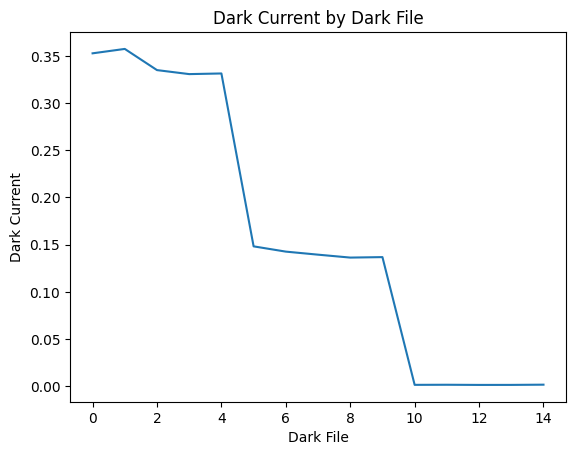

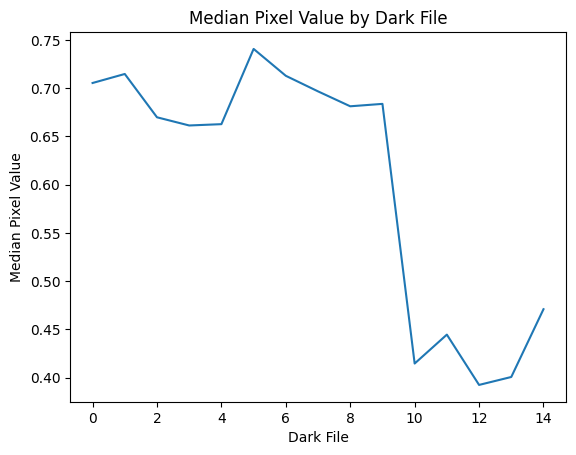

Text(0, 0.5, 'Total Pixel Value')

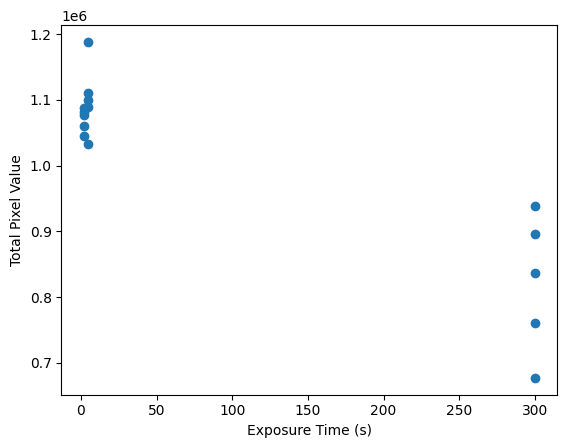

In [27]:
avg_pixel_array = []
exp_time_array = []
dark_current_array = []
tot_pixel_array = []
gain = 2.5

for dark in dark_otz_files:
    dark_otz_img, hdr = fits.getdata(dark, header=True)

    tot_pixel_val = np.sum(dark_otz_img)
    avg_pixel_val = np.median(dark_otz_img)*gain
    exptime = hdr['EXPTIME']
    dark_current = avg_pixel_val/exptime

    print('Dark File:', dark[-13:-9],
          'Exposure Time:', exptime,
          'Median Pixel Value:', avg_pixel_val,
          'Dark Current:', dark_current,
          'Total Pixel Val:', tot_pixel_val)

    avg_pixel_array.append(avg_pixel_val)
    exp_time_array.append(exptime)
    dark_current_array.append(dark_current)
    tot_pixel_array.append(tot_pixel_val)

dark_file = np.arange(0, len(dark_otz_files), 1)
plt.plot(dark_file, dark_current_array)
plt.xlabel('Dark File')
plt.ylabel(r'Dark Current')
plt.title('Dark Current by Dark File')
plt.show()

plt.plot(dark_file, avg_pixel_array)
plt.xlabel('Dark File')
plt.ylabel(r'Median Pixel Value')
plt.title('Median Pixel Value by Dark File')
plt.show()

plt.scatter(exp_time_array, tot_pixel_array)
plt.xlabel('Exposure Time (s)')
plt.ylabel('Total Pixel Value')

NOTE: The conclusions here are after overscan subtracting, trimming, and bias correcting our darks files. 

To calculate dark current, I used median pixel value to avoid outliers from cosmic rays. Mean pixel value is likely less robust to these outliers. 

The dark current is extremely low, which makes sense to me given WIRO Prime is a cryogenically cooled camera. We can see this from our 300s exposures having low dark current values! It seems like the range of dark current depends on the exposure time, but it's between ~0.0013-0.35. My personal guess is it's towards the lower end because read noise likely dominates our shorter exposure darks whereas dark signal likely dominates our higher exposure darks. We can conclude this from looking at the exposure time vs total pixel value. We can see that the fluctuations in our total pixel value are much lower for low exposure times and higher for higher exposure times. Read noise follows a random process, but likely stays fairly constant overall. We see that our higher exposure times have much more fluctuations, which probably results from dark noise. 

I asked this question over slack, but will also ask during office hours: I'm not entirely sure why my total pixel value is higher for my lower exposure darks vs my higher exposure darks because the longer exposure times should have more dark signal...couldn't figure it out before this homework is due, but wanted to put my intuition in here.

### Creating a Master Dark <a class="anchor" id="master_dark"></a>


RMS for Straight Average of All Darks 2.5775051372640623
Standard Deviation for Straight Average of All Darks 2.5664858849591803


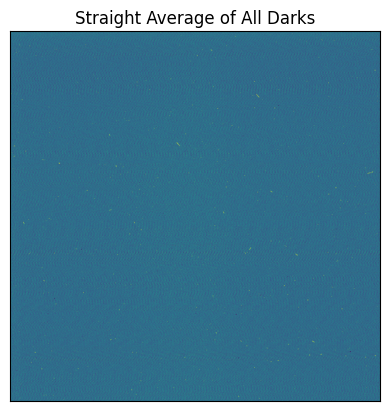

RMS for Straight Median of All Darks 2.3347346945865897
Standard Deviation for Straight Median of All Darks 2.3213808622442023


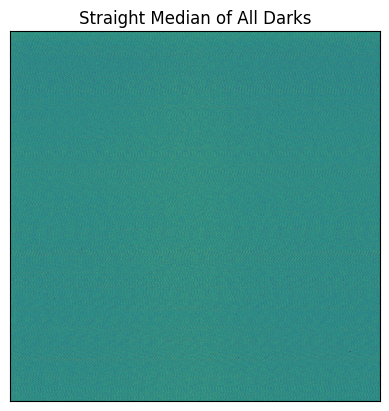

/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/imaging.venv/lib/python3.13/site-packages/ccdproc/combiner.py:569: RuntimeWarning: Mean of empty slice
  mean = scale_func(data, axis=0)
/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/imaging.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


RMS for Average of All Darks (3sigma-clipped) 2.267916392274312
Standard Deviation for Average of All Darks (3sigma-clipped) 2.2539774793029204


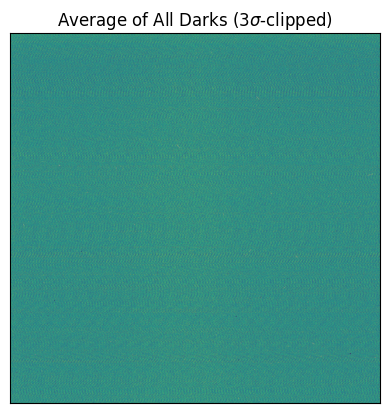

/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/imaging.venv/lib/python3.13/site-packages/ccdproc/combiner.py:462: RuntimeWarning: All-NaN slice encountered
  medianed = median_func(data, axis=0)
/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/imaging.venv/lib/python3.13/site-packages/astropy/stats/funcs.py:863: RuntimeWarning: All-NaN slice encountered
  data_median = func(data, axis=axis)
/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/imaging.venv/lib/python3.13/site-packages/astropy/stats/funcs.py:872: RuntimeWarning: All-NaN slice encountered
  result = func(np.abs(data - data_median), axis=axis, overwrite_input=True)


RMS for Median of All Darks (3sigma-clipped) 2.3440143369125
Standard Deviation for Median of All Darks (3sigma-clipped) 2.3297374937623907


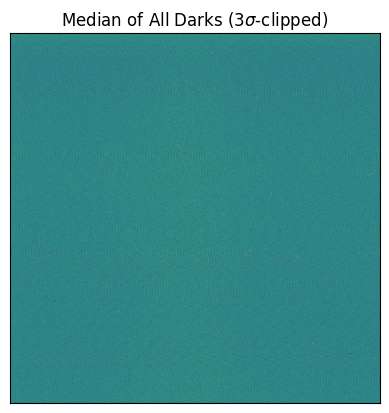

In [28]:


interval = ZScaleInterval()

avg_darks = ccdp.combine(dark_otz_files,
                           unit='adu',
                           method='average',
                           sigma_clip=False)
avg_darks_rms = np.sqrt(np.mean(np.array(avg_darks)**2))
avg_darks_std = np.std(avg_darks)
print('RMS for Straight Average of All Darks', avg_darks_rms)
print('Standard Deviation for Straight Average of All Darks', avg_darks_std)

vmin, vmax = interval.get_limits(avg_darks)
plt.imshow(avg_darks, vmin=vmin, vmax=vmax)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('Straight Average of All Darks')
plt.show()


median_darks = ccdp.combine(dark_otz_files,
                           unit='adu',
                           method='median',
                           sigma_clip=False)
median_darks_rms = np.sqrt(np.mean(np.array(median_darks)**2))
median_darks_std = np.std(median_darks)
print('RMS for Straight Median of All Darks', median_darks_rms)
print('Standard Deviation for Straight Median of All Darks', median_darks_std)

vmin, vmax = interval.get_limits(median_darks)
plt.imshow(median_darks, vmin=vmin, vmax=vmax)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('Straight Median of All Darks')
plt.show()


avg_darks_sigclip = ccdp.combine(dark_otz_files,
                                 unit='adu',
                                 method='average',
                                 sigma_clip=True,
                                 sigma_clip_low_thresh=3,
                                 sigma_clip_high_thresh=3,
                                 sigma_clip_func=np.ma.mean,
                                 sigma_clip_dev_func=mad_std
                                 )
avg_darks_sigclip_rms = np.sqrt(np.nanmean(np.array(avg_darks_sigclip)**2))
avg_darks_sigclip_std = np.nanstd(avg_darks_sigclip)
print('RMS for Average of All Darks (3sigma-clipped)', avg_darks_sigclip_rms)
print('Standard Deviation for Average of All Darks (3sigma-clipped)', avg_darks_sigclip_std)

vmin, vmax = interval.get_limits(avg_darks_sigclip)
plt.imshow(avg_darks_sigclip, vmin=vmin, vmax=vmax)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title(r'Average of All Darks ($3{\sigma}$-clipped)')
plt.show()


median_darks_sigclip = ccdp.combine(dark_otz_files,
                                 unit='adu',
                                 method='median',
                                 sigma_clip=True,
                                 sigma_clip_low_thresh=3,
                                 sigma_clip_high_thresh=3,
                                 sigma_clip_func=np.ma.mean,
                                 sigma_clip_dev_func=mad_std
                                 )
median_darks_sigclip_rms = np.sqrt(np.nanmean(np.array(median_darks_sigclip)**2))
median_darks_sigclip_std = np.nanstd(median_darks_sigclip)
print('RMS for Median of All Darks (3sigma-clipped)', median_darks_sigclip_rms)
print('Standard Deviation for Median of All Darks (3sigma-clipped)', median_darks_sigclip_std)

vmin, vmax = interval.get_limits(median_darks_sigclip)
plt.imshow(median_darks_sigclip, vmin=vmin, vmax=vmax)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title(r'Median of All Darks ($3{\sigma}$-clipped)')
plt.show()



output_path = os.path.join(output_dir, 'master_dark.fits')
fits.writeto(output_path, np.array(avg_darks_sigclip), overwrite=True)

Using the lowest RMS/standard deviation values, it seems like the best combination procedure is an average where outlier pixels are rejected if they are more than 3 sigma away from the mean. 

### Master Dark vs Master Bias<a class="anchor" id="bias_dark"></a>


In [29]:
master_dark = fits.getdata(reduced_dir+'master_dark.fits')


master_dark_median = np.nanmedian(master_dark)
master_dark_std = np.nanstd(master_dark)
snr = master_dark_median/master_dark_std

sig_threshold = master_dark_median + 3*master_dark_std
tot_pixels = np.sum(master_dark > 0)
hot_pixels = np.sum(master_dark > sig_threshold)
hot_tot_pix = hot_pixels/tot_pixels

print('The total number of pixels is:', tot_pixels)
print('The number of significantly hot pixels is', hot_pixels)
print('The percentage of hot pixels is:', 100*hot_tot_pix, '%')
print('The noise is '+str(1/snr)+'x larger than the typical dark current in the master dark')

The total number of pixels is: 2271889
The number of significantly hot pixels is 8679
The percentage of hot pixels is: 0.3820169031145448 %
The noise is 9.827969129747203x larger than the typical dark current in the master dark


We have ~8679 pixels above 3 sigma of our median dark level. Some of these are definitely hot pixels vs random noise. If we increase to 5-sigma, we see 53 pixels are above our median dark level. Our highest pixel value is ~11.5-sigma above the median dark level. These are likely very strong hot pixels that we will have to subtract out of our science images!

The noise in our master dark is ~10x higher than our dark current. This means our dark current doesn't contribute that much, but we still have noise. 

## Final Code <a class="anchor" id="final"></a>

This section includes the code that is only used to create the overscan subtracted, trimmed, bias corrected (otz) images. This is for ease of running later, but is commented out. 

The above sections contain proper methodology that should be used when thinking through how to quantitatively examine these files and how/why to correct them. 

In [30]:
# # IMPORT BLOCK

# import numpy as np
# from astropy.io import fits
# from matplotlib import pyplot as plt
# from matplotlib import rc
# %matplotlib inline
# from astropy.visualization import hist, ZScaleInterval
# from ccdproc import ImageFileCollection
# import ccdproc as ccdp
# from astropy.modeling import fitting
# from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D
# from astropy.nddata import CCDData
# from astropy import units as u
# from astropy.stats import sigma_clip, mad_std
# import glob
# import os


# ## DEFINE DATA DIRECTORY AND BIAS/DARKS/FLATS/SCIENCE FILES LISTS

# data_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/image_combination/Imaging/'
# output_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/reduced_files/'
# reduced_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/reduced_files/'

# bias_files = sorted(
#     glob.glob(data_dir+'a09[3-9].fits') + #93-99
#     glob.glob(data_dir+'a10[0-9].fits') + #100-109
#     glob.glob(data_dir+'a11[0-1].fits')   #110-111
# )

# flat_files = sorted(
#     glob.glob(data_dir+'a00[5-9].fits') + #5-9
#     glob.glob(data_dir+'a01[0-9].fits') + #10-19
#     glob.glob(data_dir+'a02[0-9].fits') + #20-29
#     glob.glob(data_dir+'a03[0-9].fits') + #30-39
#     glob.glob(data_dir+'a04[0-9].fits') + #40-49
#     glob.glob(data_dir+'a05[0-9].fits') + #50-59
#     glob.glob(data_dir+'a06[0-2].fits')   #60-62
# )

# dark_files = sorted(
#     glob.glob(data_dir+'d00[1-9].fits') + #1-9
#     glob.glob(data_dir+'d01[0-5].fits')  #10-15
# )

# pg_files = sorted(
#     glob.glob(data_dir+'a06[4-9].fits') + #64-69
#     glob.glob(data_dir+'a07[0-9].fits') + #70-79
#     glob.glob(data_dir+'a08[0-9].fits') + #80-89
#     glob.glob(data_dir+'a09[0-2].fits') + #90-92
#     glob.glob(data_dir+'a13[0-9].fits') + #130-139
#     glob.glob(data_dir+'a20[2-9].fits') + #202-209
#     glob.glob(data_dir+'a21[0-1].fits') + #210-211
#     glob.glob(data_dir+'a22[1-9].fits') + #221-229 (We don't have any of these)
#     glob.glob(data_dir+'a23[0-9].fits') + #230-239 (We only have #237-239)
#     glob.glob(data_dir+'a24[0-6].fits')   #240-246
# )

# ngc_files = sorted(
#     glob.glob(data_dir+'a15[3-9].fits') + #153-159
#     glob.glob(data_dir+'a16[0-3].fits')  #160-163
# )


# ## MAKES ALL OF OUR FILE LISTS INTO NUMPY ARRAY CUBES

# bias_array = np.array([fits.getdata(bias) for bias in bias_files])
# bias_biassec = np.array([np.concatenate((bias[:, 0:53], bias[:, 2101:]), axis=1) for bias in bias_array])
# bias_trimsec = np.array([bias[:, 53:2101] for bias in bias_array])

# flat_array = np.array([fits.getdata(flat) for flat in flat_files])
# flat_biassec = np.array([np.concatenate((flat[:, 0:53], flat[:, 2101:]), axis=1) for flat in flat_array])
# flat_trimsec = np.array([flat[:, 53:2101] for flat in flat_array])

# dark_array = np.array([fits.getdata(dark) for dark in dark_files])
# dark_biassec = np.array([np.concatenate((dark[:, 0:53], dark[:, 2101:]), axis=1) for dark in dark_array])
# dark_trimsec = np.array([dark[:, 53:2101] for dark in dark_array])

# pg_array = np.array([fits.getdata(img) for img in pg_files])
# pg_biassec = np.array([np.concatenate((img[:, 0:53], img[:, 2101:]), axis=1) for img in pg_array])
# pg_trimsec = np.array([img[:, 53:2101] for img in pg_array])

# ngc_array = np.array([fits.getdata(img) for img in ngc_files])
# ngc_biassec = np.array([np.concatenate((img[:, 0:53], img[:, 2101:]), axis=1) for img in ngc_array])
# ngc_trimsec = np.array([img[:, 53:2101] for img in ngc_array])


# ## OVERSCAN SUBTRACT AND TRIM BIAS FILES
# bias_o_array = []
# bias_ot_array = []

# for bias in bias_files:
#     bias_img, header = fits.getdata(bias, header=True)
#     ccd = CCDData(bias_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     bias_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     bias_img_ot = bias_img_o[:, 53:2101]

#     bias_o_array.append(bias_img_o)
#     bias_ot_array.append(bias_img_ot)

#     original_name = os.path.basename(bias)
#     new_name = os.path.splitext(original_name)[0]+'_ot.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, bias_img_ot, header, overwrite=True)


# ##CREATE MASTER BIAS
# bias_ot_files = sorted(
#     glob.glob(reduced_dir+'a09[3-9]_ot.fits') + #93-99
#     glob.glob(reduced_dir+'a10[0-9]_ot.fits') + #100-109
#     glob.glob(reduced_dir+'a11[0-1]_ot.fits')   #110-111
# )
# print('The number of biases we have is:', len(bias_ot_files))

# master_bias = ccdp.combine(bias_ot_files,
#                            unit='adu',
#                            method='average',
#                            sigma_clip=False)
# master_bias_array = np.array(master_bias)
# output_path = os.path.join(output_dir, 'master_bias.fits')
# fits.writeto(output_path, master_bias_array, overwrite=True)


# ##OVERSCAN SUBTRACT, TRIM, AND BIAS CORRECT EVERY FILE (USES MASTER BIAS)
# #BIASES     
# bias_o_array = []
# bias_ot_array = []
# bias_otz_array = []

# for bias in bias_files:
#     bias_img, header = fits.getdata(bias, header=True)
#     ccd = CCDData(bias_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     bias_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     bias_img_ot = bias_img_o[:, 53:2101]
#     bias_img_otz = bias_img_ot - master_bias_array

#     bias_o_array.append(bias_img_o)
#     bias_ot_array.append(bias_img_ot)
#     bias_otz_array.append(bias_img_otz)

#     original_name = os.path.basename(bias)
#     new_name = os.path.splitext(original_name)[0]+'_otz.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, bias_img_otz, header, overwrite=True)

# #FLATS     
# flat_o_array = []
# flat_ot_array = []
# flat_otz_array = []

# for flat in flat_files:
#     flat_img, header = fits.getdata(flat, header=True)
#     ccd = CCDData(flat_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     flat_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     flat_img_ot = flat_img_o[:, 53:2101]
#     flat_img_otz = flat_img_ot - master_bias_array

#     flat_o_array.append(flat_img_o)
#     flat_ot_array.append(flat_img_ot)
#     flat_otz_array.append(flat_img_otz)

#     original_name = os.path.basename(flat)
#     new_name = os.path.splitext(original_name)[0]+'_otz.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, flat_img_otz, header, overwrite=True)

# #DARKS     
# dark_o_array = []
# dark_ot_array = []
# dark_otz_array = []

# for dark in dark_files:
#     dark_img, header = fits.getdata(dark, header=True)
#     ccd = CCDData(dark_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     dark_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     dark_img_ot = dark_img_o[:, 53:2101]
#     dark_img_otz = dark_img_ot - master_bias_array

#     dark_o_array.append(dark_img_o)
#     dark_ot_array.append(dark_img_ot)
#     dark_otz_array.append(dark_img_otz)

#     original_name = os.path.basename(dark)
#     new_name = os.path.splitext(original_name)[0]+'_otz.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, dark_img_otz, header, overwrite=True)

# #PG1633    
# pg_o_array = []
# pg_ot_array = []
# pg_otz_array = []

# for img in pg_files:
#     pg_img, header = fits.getdata(img, header=True)
#     ccd = CCDData(pg_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     pg_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     pg_img_ot = pg_img_o[:, 53:2101]
#     pg_img_otz = pg_img_ot - master_bias_array

#     pg_o_array.append(pg_img_o)
#     pg_ot_array.append(pg_img_ot)
#     pg_otz_array.append(pg_img_otz)

#     original_name = os.path.basename(img)
#     new_name = os.path.splitext(original_name)[0]+'_otz.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, pg_img_otz, header, overwrite=True)

# #NGC6823    
# ngc_o_array = []
# ngc_ot_array = []
# ngc_otz_array = []

# for img in ngc_files:
#     ngc_img, header = fits.getdata(img, header=True)
#     ccd = CCDData(ngc_img, unit=u.adu)
#     overscan = np.concatenate((ccd.data[:, 0:53], ccd.data[:, 2101:]), axis=1)
#     overscan_ccd = CCDData(overscan, unit=ccd.unit)
    
#     ngc_img_o = ccdp.subtract_overscan(ccd, 
#                                 overscan = overscan_ccd, 
#                                 overscan_axis = 1,
#                                 model = Polynomial1D(degree=3)
#                                 ).data
    
#     ngc_img_ot = ngc_img_o[:, 53:2101]
#     ngc_img_otz = ngc_img_ot - master_bias_array

#     ngc_o_array.append(ngc_img_o)
#     ngc_ot_array.append(ngc_img_ot)
#     ngc_otz_array.append(ngc_img_otz)

#     original_name = os.path.basename(img)
#     new_name = os.path.splitext(original_name)[0]+'_otz.fits'
#     output_path = os.path.join(output_dir, new_name)
#     fits.writeto(output_path, ngc_img_otz, header, overwrite=True)
